In [88]:
import pandas as pd
import networkx as nx
import ast
import numpy as np

In [89]:
PROCESSED_STATIONS_DF = "data/processed/stations_data.csv"

# bounding box
MAX_LAT = 45
MIN_LAT = 32
MAX_LNG = -67
MIN_LNG = -120

# Truck properties
RANGE = 305.7 #km. in miles its 190 miles

"""
~~~ ORIGINAL (for a 100 kwh station) ~~~
[1, 10]: 35 seconds each percentage point
[11, 40]: 25
[41, 60]: 30
[61, 80]: 45
[81, 90]: 80
[91, 95]: 130
[96, 100]: 400
~~~

time to charge to 80 (in seconds): 10 * 35 + 29 * 25 + 19 * 30 + 19 * 45 = 2500s
time to charge to 80 at a 100 kwh station should be 60min * 25/10 = 9000s

~~~ Scaled (for a 100 kwh station) ~~~
[1, 10]: 35 * 3.6 seconds each percentage point
[11, 40]: 25 * 3.6
[41, 60]: 30 * 3.6
[61, 80]: 45 * 3.6
[81, 90]: 80 * 3.6
[91, 95]: 130 * 3.6
[96, 100]: 400 * 3.6
~~~

"""

# for a 100kwh station,
speed_curve ={0: {'speed': 3600 * 1/(35*3.6), 'minbat': 0, 'maxbat': 11}, \
                   1: {'speed': 3600 * 1/(25*3.6), 'minbat': 11, 'maxbat': 41}, \
                   2: {'speed': 3600 * 1/(30*3.6), 'minbat': 41, 'maxbat': 61}, \
                   3: {'speed': 3600 * 1/(45*3.6), 'minbat': 61, 'maxbat': 81}, \
                   4: {'speed': 3600 * 1/(80*3.6), 'minbat': 81, 'maxbat': 91}, \
                   5: {'speed': 3600 * 1/(130*3.6), 'minbat': 91, 'maxbat': 96}, \
                   6: {'speed': 3600 * 1/(400 * 3.6), 'minbat': 96, 'maxbat': 100}} # speed = amt per hour


# Other parameters
BAT_FROM_TIME = 3600 * 1000 * .75 # battery consumption = (3600 * 1000 * .8) * (time in hrs)


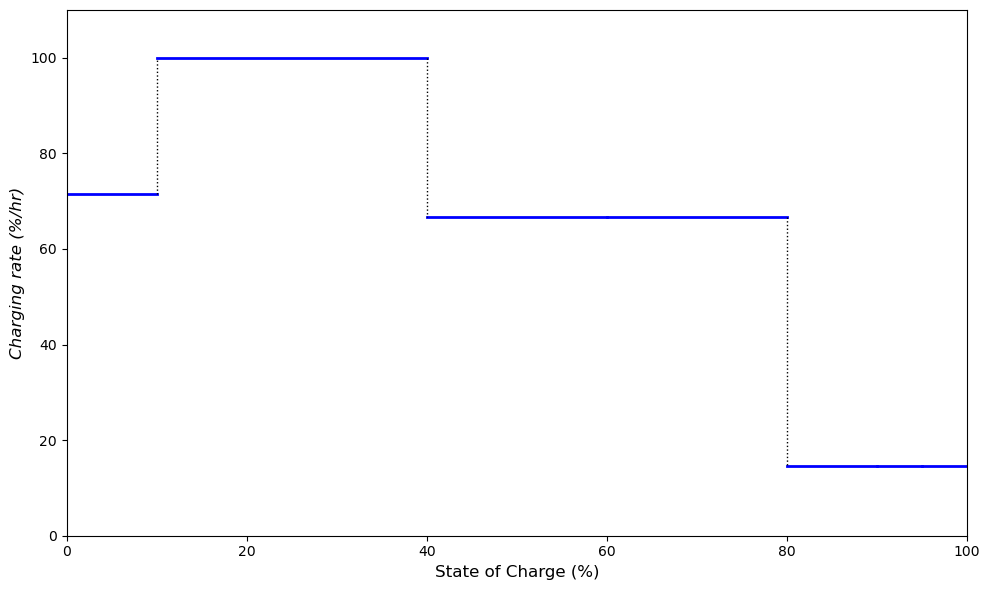


Charging rates for 250 kWh charger:
    0% -  10%: 71.4 %/hr
   10% -  40%: 100.0 %/hr
   40% -  60%: 66.7 %/hr
   60% -  80%: 66.7 %/hr
   80% -  90%: 14.5 %/hr
   90% -  95%: 14.5 %/hr
   95% - 100%: 14.5 %/hr


In [90]:
# Generate charging rate vs state of charge plot for 250 kWh charger
import matplotlib.pyplot as plt

# Charging curve data (based on speed_curve, scaled for 250 kWh charger)
# Original speed_curve is for 100 kWh, so multiply by 2.5 for 250 kWh
CHARGER_KW = 250
SCALE_FACTOR = CHARGER_KW / 100

# Original charging rates for 100 kWh (in % per hour)
# speed = 3600 / (seconds_per_percent * 3.6)
base_rates = {
    (0, 10): 3600 / (35 * 3.6),    # ~28.6 %/hr
    (10, 40): 3600 / (25 * 3.6),   # 40 %/hr
    (40, 60): 3600 / (37.5 * 3.6),   # ~33.3 %/hr
    (60, 80): 3600 / (37.5 * 3.6),   # ~22.2 %/hr
    (80, 90): 3600 / (172.5 * 3.6),   # 12.5 %/hr
    (90, 95): 3600 / (172.5 * 3.6),  # ~7.7 %/hr
    (95, 100): 3600 / (172.5 * 3.6), # 2.5 %/hr
}

# Scale rates for 250 kWh charger
scaled_rates = {k: v * SCALE_FACTOR for k, v in base_rates.items()}

# Build step function data
soc_points = []
rate_points = []

for (soc_min, soc_max), rate in scaled_rates.items():
    soc_points.extend([soc_min, soc_max])
    rate_points.extend([rate, rate])

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

# Draw horizontal segments with dotted vertical connectors
prev_soc = None
prev_rate = None
for (soc_min, soc_max), rate in scaled_rates.items():
    # Horizontal segment
    ax.plot([soc_min, soc_max], [rate, rate], 'b-', linewidth=2)
    # Vertical connector (dotted)
    if prev_rate is not None:
        ax.plot([soc_min, soc_min], [prev_rate, rate], 'k:', linewidth=1)
    prev_soc = soc_max
    prev_rate = rate

ax.set_xlabel('State of Charge (%)', fontsize=12)
ax.set_ylabel('Charging rate (%/hr)', fontsize=12, style='italic')
ax.set_xlim(0, 100)
ax.set_ylim(0, 110)
ax.grid(False)

plt.tight_layout()
plt.savefig('charge_rate_250_generated.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nCharging rates for {CHARGER_KW} kWh charger:")
for (soc_min, soc_max), rate in scaled_rates.items():
    print(f"  {soc_min:3d}% - {soc_max:3d}%: {rate:.1f} %/hr")

In [91]:
other_nodes_df = pd.read_csv("data/D_clean_Jun12.csv")
stations_df = pd.read_csv(PROCESSED_STATIONS_DF)

stations_df['snap_to'] = stations_df['snap_to'].apply(ast.literal_eval)
stations_df.reset_index(inplace=True)

stations_df.index = stations_df['index']
stations_df

,level_0,Unnamed: 0,lat,lng,total_chargers_at_stat,snap_to,dist_snap,type,n_chargers,kw,index
index,,,,,,,,,,,
2905,0,2905,32.765879,-96.875461,1,"(32.76062, -96.89269)",2539.0,9,1,16.0,2905
7168,1,7168,33.039075,-117.284200,2,"(33.02008, -117.28097)",2550.0,2,2,7.0,7168
1632,2,1632,33.302143,-111.955286,2,"(33.30006, -111.96835)",1654.0,2,2,7.0,1632
1302,3,1302,33.387438,-110.760985,1,"(33.39639, -110.76888)",2707.0,9,1,16.0,1302
4473,4,4473,33.788588,-118.215083,2,"(33.7822, -118.2108)",1195.0,2,2,7.0,4473
...,...,...,...,...,...,...,...,...,...,...,...
3178,57,3178,44.058535,-70.425398,1,"(43.970783, -70.609685)",22630.0,9,1,16.0,3178
7753,58,7753,44.562589,-69.658882,2,"(44.590314, -69.289139)",35234.0,2,2,7.0,7753
4578,59,4578,44.563025,-72.597691,2,"(44.680358, -72.36351)",31158.0,2,2,7.0,4578


In [92]:
# Find the largest subset of nodes where no pair is within 30 miles
# This is the Maximum Independent Set problem on the proximity graph

from math import radians, sin, cos, sqrt, atan2

def haversine_miles(lat1, lng1, lat2, lng2):
    """Calculate distance in miles between two lat/lng points."""
    R = 3958.8  # Earth's radius in miles
    
    lat1, lng1, lat2, lng2 = map(radians, [lat1, lng1, lat2, lng2])
    dlat = lat2 - lat1
    dlng = lng2 - lng1
    
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlng/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    
    return R * c

def is_west_coast(lat, lng):
    """Check if a point is within the West Coast bounding box."""
    return (WEST_COAST_MIN_LAT <= lat <= WEST_COAST_MAX_LAT and 
            WEST_COAST_MIN_LNG <= lng <= WEST_COAST_MAX_LNG)

# Get unique nodes from other_nodes_df (West Coast only)
west_coast_nodes = [node for node in all_other_nodes if is_west_coast(node[0], node[1])]

DISTANCE_THRESHOLD = 10  # miles

# Build conflict graph: nodes connected if within 30 miles of each other
conflict_graph = nx.Graph()
conflict_graph.add_nodes_from(range(len(west_coast_nodes)))

for i in range(len(west_coast_nodes)):
    for j in range(i + 1, len(west_coast_nodes)):
        lat1, lng1 = west_coast_nodes[i]
        lat2, lng2 = west_coast_nodes[j]
        dist = haversine_miles(lat1, lng1, lat2, lng2)
        if dist <= DISTANCE_THRESHOLD:
            conflict_graph.add_edge(i, j)

print(f"Conflict graph: {conflict_graph.number_of_nodes()} nodes, {conflict_graph.number_of_edges()} edges")

# Find maximum independent set using networkx approximation
# (exact MIS is NP-hard, but approximation works well for this size)
independent_set_indices = nx.approximation.maximum_independent_set(conflict_graph)

# Convert indices back to coordinates
max_independent_set = [west_coast_nodes[i] for i in independent_set_indices]

print(f"\nMaximum independent set size: {len(max_independent_set)}")
print(f"(Out of {len(west_coast_nodes)} West Coast nodes)")
print(f"\nThese {len(max_independent_set)} nodes are all more than {DISTANCE_THRESHOLD} miles apart from each other:")
for node in sorted(max_independent_set):
    print(f"  {node}")

Conflict graph: 143 nodes, 263 edges

Maximum independent set size: 67
(Out of 143 West Coast nodes)

These 67 nodes are all more than 10 miles apart from each other:
  (32.596725, -117.019495)
  (32.794671, -115.539473)
  (32.978339, -117.034924)
  (33.02008, -117.28097)
  (33.545881, -117.191846)
  (33.603063, -114.598023)
  (33.676026, -117.764558)
  (33.71397, -117.996294)
  (33.7441, -118.19161)
  (33.862772, -117.234706)
  (33.887527, -117.571533)
  (33.899899, -118.207088)
  (33.904195, -116.552357)
  (33.919681, -117.940717)
  (33.952886, -118.377315)
  (34.02094, -117.385415)
  (34.059216, -117.722362)
  (34.118101, -116.45646)
  (34.123436, -118.258072)
  (34.138664, -117.923766)
  (34.23702, -118.597759)
  (34.247415, -118.405835)
  (34.421443, -119.684178)
  (34.539391, -117.2962)
  (34.61812, -120.18705)
  (34.65054, -120.4583)
  (34.689589, -118.130371)
  (34.81936, -120.23188)
  (34.886448, -117.079423)
  (34.919891, -120.47825)
  (35.125636, -118.408202)
  (35.210277, -

In [93]:
# Find closest nodes to San Francisco and Los Angeles, compute graph distance

SF_COORDS = (37.7749, -122.4194)
LA_COORDS = (34.0522, -118.2437)

def find_closest_node(target_lat, target_lng, node_list):
    """Find the node in node_list closest to target coordinates."""
    min_dist = float('inf')
    closest_node = None
    closest_idx = None
    for idx, node in enumerate(node_list):
        dist = haversine_miles(target_lat, target_lng, node[0], node[1])
        if dist < min_dist:
            min_dist = dist
            closest_node = node
            closest_idx = idx
    return closest_idx, closest_node, min_dist

if 'all_selected_nodes' in dir() and 'G_combined' in dir():
    # Find closest nodes to SF and LA
    sf_idx, sf_node, sf_dist = find_closest_node(SF_COORDS[0], SF_COORDS[1], all_selected_nodes)
    la_idx, la_node, la_dist = find_closest_node(LA_COORDS[0], LA_COORDS[1], all_selected_nodes)
    
    print("=" * 60)
    print("SAN FRANCISCO TO LOS ANGELES")
    print("=" * 60)
    print(f"San Francisco: {SF_COORDS}")
    print(f"  Closest node: {sf_node}")
    print(f"  Distance to SF: {sf_dist:.1f} miles")
    print()
    print(f"Los Angeles: {LA_COORDS}")
    print(f"  Closest node: {la_node}")
    print(f"  Distance to LA: {la_dist:.1f} miles")
    print()
    
    # Compute shortest path in graph
    if nx.has_path(G_combined, sf_idx, la_idx):
        path_length = nx.dijkstra_path_length(G_combined, sf_idx, la_idx, weight='weight')
        path = nx.dijkstra_path(G_combined, sf_idx, la_idx, weight='weight')
        
        print(f"Shortest path distance (in graph): {path_length:.1f} miles")
        print(f"Number of hops: {len(path) - 1}")
        print()
        print("Path:")
        for i, node_idx in enumerate(path):
            node = all_selected_nodes[node_idx]
            print(f"  {i}: {node}")
    else:
        print("No path exists between SF and LA in the graph!")
    
    # Also show direct (as-the-crow-flies) distance
    direct_dist = haversine_miles(SF_COORDS[0], SF_COORDS[1], LA_COORDS[0], LA_COORDS[1])
    print()
    print(f"Direct distance (as-the-crow-flies): {direct_dist:.1f} miles")
    print("=" * 60)
else:
    print("Run the previous cells first to build the graph.")

SAN FRANCISCO TO LOS ANGELES
San Francisco: (37.7749, -122.4194)
  Closest node: (37.88175, -122.306259)
  Distance to SF: 9.6 miles

Los Angeles: (34.0522, -118.2437)
  Closest node: (34.123436, -118.258072)
  Distance to LA: 5.0 miles

Shortest path distance (in graph): 344.6 miles
Number of hops: 2

Path:
  0: (37.88175, -122.306259)
  1: (35.6157, -119.65721)
  2: (34.123436, -118.258072)

Direct distance (as-the-crow-flies): 347.4 miles


STATISTICS
Blue nodes (stations):              14
Green nodes (independent set):      67
Total unique nodes:                 81
Edge threshold for connectivity:    300 miles
Number of edges in combined graph:  2443


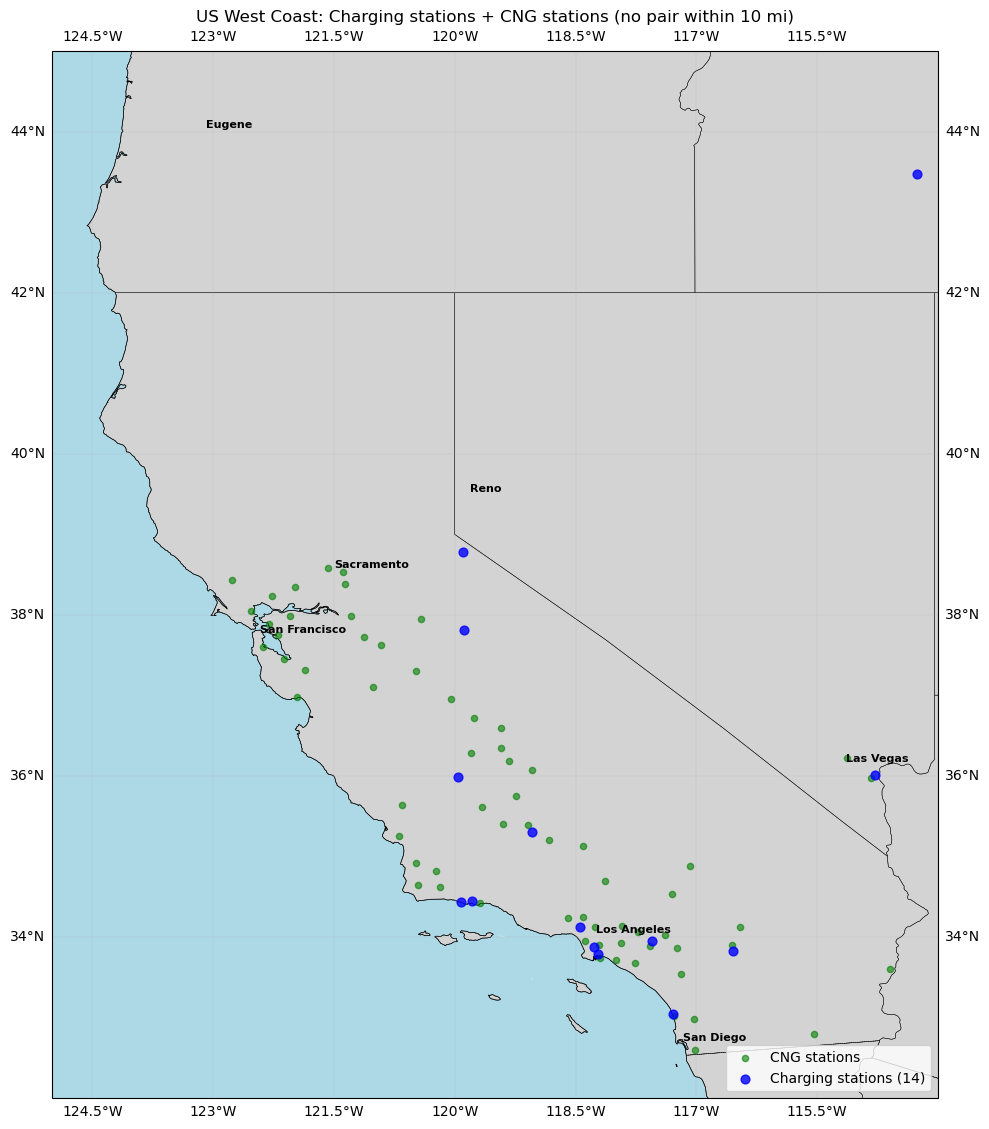

In [94]:
# Print statistics and plot the final node set

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# West Coast bounding box
WEST_COAST_MIN_LAT = 32
WEST_COAST_MAX_LAT = 45
WEST_COAST_MIN_LNG = -125
WEST_COAST_MAX_LNG = -114

# Major West Coast cities (name, lat, lng)
cities = [
    ('Seattle', 47.6062, -122.3321),
    ('Portland', 45.5152, -122.6784),
    ('San Francisco', 37.7749, -122.4194),
    ('Los Angeles', 34.0522, -118.2437),
    ('San Diego', 32.7157, -117.1611),
    ('Sacramento', 38.5816, -121.4944),
    ('Las Vegas', 36.1699, -115.1398),
    ('Phoenix', 33.4484, -112.0740),
    ('Reno', 39.5296, -119.8138),
    ('Eugene', 44.0521, -123.0868),
]

# Extract unique nodes from other_nodes_df (pt1 and pt2 are coordinate tuples as strings)
other_nodes_df['pt1'] = other_nodes_df['pt1'].apply(lambda x: x if isinstance(x, tuple) else ast.literal_eval(x))
other_nodes_df['pt2'] = other_nodes_df['pt2'].apply(lambda x: x if isinstance(x, tuple) else ast.literal_eval(x))

# Get unique coordinates from both pt1 and pt2
all_other_nodes = set(other_nodes_df['pt1'].tolist() + other_nodes_df['pt2'].tolist())

# Filter stations_df for West Coast
stations_west = stations_df[
    (stations_df['lat'] >= WEST_COAST_MIN_LAT) & 
    (stations_df['lat'] <= WEST_COAST_MAX_LAT) &
    (stations_df['lng'] >= WEST_COAST_MIN_LNG) & 
    (stations_df['lng'] <= WEST_COAST_MAX_LNG)
]

# Get station coordinates as tuples
station_coords = set(zip(stations_west['lat'], stations_west['lng']))

# Combine stations + independent set for graph analysis
if 'max_independent_set' in dir():
    all_selected_nodes = list(station_coords) + list(max_independent_set)
    all_selected_nodes = list(set(all_selected_nodes))  # Remove duplicates
    
    # Build complete graph with haversine distances
    from math import radians, sin, cos, sqrt, atan2
    
    def haversine_miles(lat1, lng1, lat2, lng2):
        R = 3958.8
        lat1, lng1, lat2, lng2 = map(radians, [lat1, lng1, lat2, lng2])
        dlat = lat2 - lat1
        dlng = lng2 - lng1
        a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlng/2)**2
        c = 2 * atan2(sqrt(a), sqrt(1-a))
        return R * c
    
    # Build graph connecting nodes within reasonable driving distance (e.g., 300 miles)
    G_combined = nx.Graph()
    for i, node1 in enumerate(all_selected_nodes):
        G_combined.add_node(i, pos=node1)
    
    EDGE_THRESHOLD = 300  # miles - max edge length for connectivity
    for i in range(len(all_selected_nodes)):
        for j in range(i + 1, len(all_selected_nodes)):
            lat1, lng1 = all_selected_nodes[i]
            lat2, lng2 = all_selected_nodes[j]
            dist = haversine_miles(lat1, lng1, lat2, lng2)
            if dist <= EDGE_THRESHOLD:
                G_combined.add_edge(i, j, weight=dist)
    
    # Compute statistics
    print("=" * 60)
    print("STATISTICS")
    print("=" * 60)
    print(f"Blue nodes (stations):              {len(stations_west)}")
    print(f"Green nodes (independent set):      {len(max_independent_set)}")
    print(f"Total unique nodes:                 {len(all_selected_nodes)}")
    print(f"Edge threshold for connectivity:    {EDGE_THRESHOLD} miles")
    print(f"Number of edges in combined graph:  {G_combined.number_of_edges()}")
    
#     if nx.is_connected(G_combined):
#         # Compute diameter (longest shortest path)
#         diameter_hops = nx.diameter(G_combined)
        
#         # Find the actual longest shortest path (by distance)
#         max_path_dist = 0
#         max_path_pair = None
#         for i in range(len(all_selected_nodes)):
#             lengths = nx.single_source_dijkstra_path_length(G_combined, i, weight='weight')
#             for j, dist in lengths.items():
#                 if dist > max_path_dist:
#                     max_path_dist = dist
#                     max_path_pair = (i, j)
        
#         print(f"\nGraph is CONNECTED")
#         print(f"Diameter (in hops):                 {diameter_hops}")
#         print(f"Longest shortest path (by dist):   {max_path_dist:.1f} miles")
#         if max_path_pair:
#             print(f"  From: {all_selected_nodes[max_path_pair[0]]}")
#             print(f"  To:   {all_selected_nodes[max_path_pair[1]]}")
#     else:
#         components = list(nx.connected_components(G_combined))
#         print(f"\nGraph is NOT CONNECTED")
#         print(f"Number of connected components:     {len(components)}")
#         print(f"Largest component size:             {max(len(c) for c in components)}")
    print("=" * 60)

# Plot with map background
fig = plt.figure(figsize=(10, 12))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Set map extent
ax.set_extent([WEST_COAST_MIN_LNG, WEST_COAST_MAX_LNG, WEST_COAST_MIN_LAT, WEST_COAST_MAX_LAT], crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.3)

# Plot independent set nodes in green
if 'max_independent_set' in dir():
    indep_lats = [node[0] for node in max_independent_set]
    indep_lngs = [node[1] for node in max_independent_set]
    ax.scatter(indep_lngs, indep_lats, c='green', s=20, alpha=0.6, 
               label=f'CNG stations', transform=ccrs.PlateCarree(), zorder=5)

# Plot stations in blue
ax.scatter(stations_west['lng'], stations_west['lat'], c='blue', s=40, alpha=0.8, 
           label=f'Charging stations ({len(stations_west)})', transform=ccrs.PlateCarree(), zorder=6)

# Add city labels only (no markers)
for city, lat, lng in cities:
    if WEST_COAST_MIN_LAT <= lat <= WEST_COAST_MAX_LAT and WEST_COAST_MIN_LNG <= lng <= WEST_COAST_MAX_LNG:
        ax.text(lng, lat, city, fontsize=8, fontweight='bold', 
                transform=ccrs.PlateCarree(), zorder=8)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('US West Coast: Charging stations + CNG stations (no pair within 10 mi)')
ax.legend(loc='lower right')
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
plt.tight_layout()
plt.show()